# 04 - Transfer learning com ResNet18

**Objetivo:** usar uma rede já treinada (ResNet18, treinada com 1,2 milhão de fotos comuns do ImageNet) e adaptá-la para NORMAL/PNEUMONIA, comparando com a CNN simples do notebook anterior.

**Por que isso costuma funcionar melhor?** As primeiras camadas de uma CNN aprendem padrões bem genéricos (bordas, texturas, formas), úteis para qualquer tipo de imagem. A ResNet18 já aprendeu isso muito bem, com muito mais dados do que os nossos milhares de radiografias. Reaproveitamos esse conhecimento e treinamos só a parte final, que decide entre as nossas duas classes.

Assim como no notebook anterior, avaliamos aqui só na **validação**. O `test` fica reservado para a comparação final entre os dois modelos.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from src import dados, modelos, treino

torch.manual_seed(42)

PASTA_FIGURAS = Path("..") / "reports" / "figures"
PASTA_MODELOS = Path("..") / "models"

dispositivo = treino.escolher_dispositivo()
print("Dispositivo:", dispositivo)

Dispositivo: mps


In [2]:
loaders, tabelas = dados.criar_dataloaders(tamanho_lote=32)
pesos_classe = dados.pesos_de_classe(tabelas["treino"])

## 2. O modelo

`resnet18_transferencia` (em [`src/modelos.py`](../src/modelos.py)) carrega a ResNet18 pré-treinada, **congela** todas as camadas convolucionais (elas não mudam durante o treino) e troca a camada final por uma nova, com 2 saídas em vez de 1000.

Repare a diferença: a CNN simples tinha ~98 mil parâmetros, todos treináveis. Aqui só a camada final (pouco mais de mil parâmetros) é treinada; o resto (mais de 11 milhões) já vem pronto do ImageNet.

In [3]:
modelo = modelos.resnet18_transferencia()

treinaveis = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo.parameters())
print(f"Parâmetros treináveis: {treinaveis:,}")
print(f"Parâmetros totais:     {total:,}")
print()
print("Última camada (a única treinada):", modelo.fc)

Parâmetros treináveis: 1,026
Parâmetros totais:     11,177,538

Última camada (a única treinada): Linear(in_features=512, out_features=2, bias=True)


## 3. Treino

Mesmas configurações do baseline, para a comparação ser justa:
- **10 épocas**, Adam com taxa de aprendizado `0.001`, perda com pesos de classe.
- Os melhores pesos (menor perda na validação) são salvos em `models/resnet18.pt`.

Como só a camada final é treinada, cada época deveria ser tão rápida quanto a da CNN simples (o tempo é dominado por carregar e transformar as imagens, não pelo tamanho do modelo).

In [4]:
historico = treino.treinar(
    modelo, loaders, pesos_classe,
    epocas=10,
    taxa_aprendizado=1e-3,
    caminho_pesos=PASTA_MODELOS / "resnet18.pt",
    dispositivo=dispositivo,
)

Época  1/10 | treino: perda 0.373 acc 0.853 | val: perda 0.438 acc 0.809 recall 0.745 | 85s  <- melhor até agora


Época  2/10 | treino: perda 0.241 acc 0.909 | val: perda 0.213 acc 0.928 recall 0.912 | 824s  <- melhor até agora


Época  3/10 | treino: perda 0.235 acc 0.914 | val: perda 0.263 acc 0.908 recall 0.881 | 89s


Época  4/10 | treino: perda 0.207 acc 0.920 | val: perda 0.326 acc 0.873 recall 0.831 | 516s


Época  5/10 | treino: perda 0.198 acc 0.926 | val: perda 0.177 acc 0.940 recall 0.928 | 116s  <- melhor até agora


Época  6/10 | treino: perda 0.190 acc 0.925 | val: perda 0.195 acc 0.938 recall 0.924 | 174s


Época  7/10 | treino: perda 0.183 acc 0.929 | val: perda 0.166 acc 0.948 recall 0.938 | 86s  <- melhor até agora


Época  8/10 | treino: perda 0.179 acc 0.933 | val: perda 0.169 acc 0.946 recall 0.937 | 86s


Época  9/10 | treino: perda 0.174 acc 0.931 | val: perda 0.205 acc 0.932 recall 0.916 | 559s


Época 10/10 | treino: perda 0.162 acc 0.941 | val: perda 0.248 acc 0.917 recall 0.893 | 88s


## 4. Curvas de aprendizado

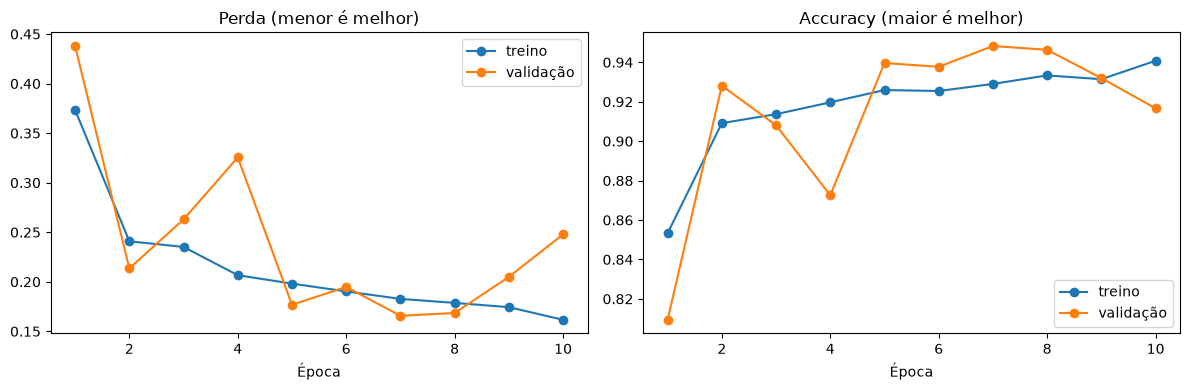

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].plot(historico["epoca"], historico["perda_treino"], marker="o", label="treino")
eixos[0].plot(historico["epoca"], historico["perda_val"], marker="o", label="validação")
eixos[0].set_title("Perda (menor é melhor)")

eixos[1].plot(historico["epoca"], historico["acc_treino"], marker="o", label="treino")
eixos[1].plot(historico["epoca"], historico["acc_val"], marker="o", label="validação")
eixos[1].set_title("Accuracy (maior é melhor)")

for eixo in eixos:
    eixo.set_xlabel("Época")
    eixo.legend()
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "04_resnet18_curvas.png", dpi=120)
plt.show()

## 5. Desempenho na validação

In [6]:
criterio = torch.nn.CrossEntropyLoss(weight=pesos_classe.to(dispositivo))
_, rotulos_val, previsoes_val = treino.avaliar(modelo, loaders["val"], criterio, dispositivo)

print(classification_report(rotulos_val, previsoes_val, target_names=dados.CLASSES, digits=3))

              precision    recall  f1-score   support

      NORMAL      0.846     0.978     0.907       269
   PNEUMONIA      0.992     0.938     0.964       775

    accuracy                          0.948      1044
   macro avg      0.919     0.958     0.936      1044
weighted avg      0.954     0.948     0.949      1044



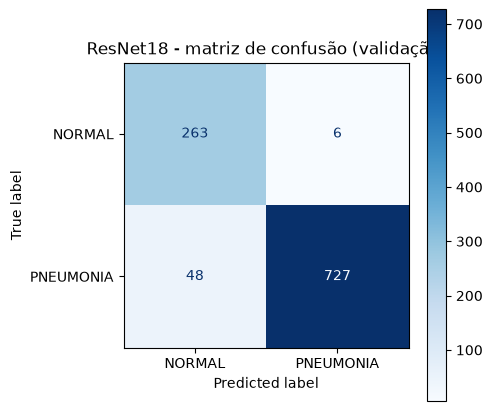

In [7]:
fig, eixo = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    rotulos_val, previsoes_val, display_labels=dados.CLASSES, cmap="Blues", ax=eixo
)
eixo.set_title("ResNet18 - matriz de confusão (validação)")
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "04_resnet18_confusao_val.png", dpi=120)
plt.show()

## 6. Comparando com a CNN simples

Uma tabela lado a lado com os dois modelos, na mesma validação.

In [8]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Recarrega a CNN simples com os pesos salvos no notebook anterior, para comparar
cnn_simples = modelos.CNNSimples().to(dispositivo)
cnn_simples.load_state_dict(torch.load(PASTA_MODELOS / "cnn_simples.pt", map_location=dispositivo))
_, rotulos_cnn, previsoes_cnn = treino.avaliar(cnn_simples, loaders["val"], criterio, dispositivo)

comparacao = pd.DataFrame([
    {
        "modelo": "CNN simples",
        "accuracy": accuracy_score(rotulos_cnn, previsoes_cnn),
        "recall_pneumonia": recall_score(rotulos_cnn, previsoes_cnn, pos_label=1),
        "f1_pneumonia": f1_score(rotulos_cnn, previsoes_cnn, pos_label=1),
    },
    {
        "modelo": "ResNet18 (transfer learning)",
        "accuracy": accuracy_score(rotulos_val, previsoes_val),
        "recall_pneumonia": recall_score(rotulos_val, previsoes_val, pos_label=1),
        "f1_pneumonia": f1_score(rotulos_val, previsoes_val, pos_label=1),
    },
]).set_index("modelo").round(3)
comparacao

,accuracy,recall_pneumonia,f1_pneumonia
modelo,,,
CNN simples,0.963,0.982,0.975
ResNet18 (transfer learning),0.948,0.938,0.964


## 7. Conclusões

| Métrica (validação) | CNN simples | ResNet18 (transfer learning) |
|---|---|---|
| Accuracy | 96,3% | 94,8% |
| Recall PNEUMONIA | 98,2% | 93,8% |
| Precisão PNEUMONIA | 96,8% | 99,2% |
| F1 PNEUMONIA | 97,5% | 96,4% |
| Recall NORMAL | 90,7% | 97,8% |

**Resultado surpreendente: a CNN simples, treinada do zero, teve recall de pneumonia melhor que a ResNet18 com transfer learning.** Isso vai contra a expectativa inicial (o plano do projeto esperava a ResNet18 vencer), então vale entender o porquê:

1. **Só a camada final foi treinada** (1.026 parâmetros, contra 11 milhões congelados). Isso é chamado de *linear probing*: rápido e evita estragar os pesos do ImageNet, mas é bem menos flexível do que treinar a rede inteira.
2. **As radiografias são bem diferentes das fotos do ImageNet.** A ResNet18 aprendeu seus padrões (bordas, texturas, formas) com fotos comuns coloridas (gatos, carros, objetos do dia a dia). Radiografias são em tons de cinza e têm uma estrutura visual bem particular; parte do que a rede "sabe" pode não ser tão útil aqui.
3. **A CNN simples, mesmo pequena, foi treinada do zero direto nas radiografias**, então toda a sua capacidade (limitada, mas 100% dela) foi usada para aprender exatamente esse problema.
4. A ResNet18 teve **recall de NORMAL melhor** (97,8% contra 90,7%) e **precisão de PNEUMONIA melhor** (99,2% contra 96,8%): ela erra menos ao dizer "pneumonia" para quem não tem, mas deixa passar mais casos reais de pneumonia. Como o recall de pneumonia é a métrica que definimos como principal (deixar passar uma doença é o erro mais grave em triagem), isso pesa contra a ResNet18 neste cenário.
5. **Curva de validação também instável** aqui (por exemplo, queda na época 4), parecida com o que vimos na CNN simples. Sinal de que 10 épocas com essa taxa de aprendizado deixam o treino sensível a esse conjunto de validação pequeno.

**O que isso não significa:** não quer dizer que transfer learning "não funciona" para este problema. Um próximo passo natural (fora do escopo deste projeto por ora) seria *fine-tuning*: descongelar as últimas camadas convolucionais e treiná-las com uma taxa de aprendizado bem pequena, deixando a rede adaptar seus filtros às radiografias em vez de só reaproveitá-los prontos. Registramos essa possibilidade como trabalho futuro.

**Decisão:** com a métrica principal sendo o recall de pneumonia, a **CNN simples** está à frente na validação. Mesmo assim, vamos avaliar **os dois modelos** no conjunto de teste (notebook seguinte), porque é a medida final e mais confiável, e a validação (1044 imagens) pode não contar toda a história.

**Próximo passo:** avaliar os dois modelos no conjunto de **teste**, que ainda não foi tocado, e usar Grad-CAM no modelo escolhido para visualizar em quais regiões da radiografia ele se baseia.